# Neural network architectures against classical benchmarks on a
# ten-year multi-line company set

Two reserving architectures are compared here against classical benchmarks on the same
companies, the same accident years and the same held-out cells. One is `tlrn`, a
development-factor transformer that reads a company's four lines of business jointly and
predicts the log development factor of every line at every lag. The other is
`nn_transformer`, ibnr's cell-token transformer with a mixture density head. The
benchmarks are Mack's distribution-free chain ladder, the full-matrix multivariate chain
ladder (`mcl`) and the seemingly-unrelated-regressions chain ladder (`sur`).

The data are NAIC Schedule P triangles from the CAS loss reserving database: accident
years 1998 through 2007, valued at 31 December 2007, on four lines - commercial auto,
other liability, private passenger auto and workers compensation. The cohort set is 243
company-line pairs over 93 companies, chosen once by a fixed rule and used by every
model.

## The three comparison levels

Errors are summed within a level before the absolute value is taken, so the level decides
how much cancellation between lines a model is credited with. Every table below names its
level.

| level | unit | count |
|---|---|---|
| next calendar diagonal | one paid cell | 243 pairs x 9 cells = 2,187 |
| 120-month endpoint | one company-line pair | 243 |
| company reserve | one company | 82 |

The company reserve level is the companion study's own, and it runs on 82 of the 93
companies: the other eleven have a zero or negative cumulative paid on a cell that a
development transition divides by, which `mcl` and `mack` both refuse by name. The
selection section lists them.

## Vocabulary

* **cohort set** - the fixed list of companies and company-line pairs every model is fit
  and scored on. It is never quietly shrunk when one model refuses a fit.
* **level** - the unit errors are summed within before the absolute value is taken.
* **point** - a deterministic forecast number. Every entry has draws; `mack`, `mcl` and
  `tlrn` also have a native `point()`.
* **reserve** - ultimate minus the cumulative observed at the valuation date.
* **ultimate** - the 120-month endpoint of this grid. There is no tail factor anywhere in
  this notebook, so "ultimate" always means that endpoint and never a true run-off.

## The reproduction target

The reference implementation of the companion study was replayed on 2026-09-20 on data
loaded through ibnr. Its company-level Pool_APE over the 82 companies:

| row | Pool_APE |
|---|---|
| chain ladder | 5.7732% |
| chain ladder + MCL | 5.6606% |
| raw transformer | 5.6256% |
| blended transformer | 5.0880% |

Those four numbers are quoted below as constants. `mcl` and `mack` are expected to
reproduce the reference reserves exactly, and the notebook asserts that to 1e-6 relative.
The transformer is not: R torch and Python torch draw different random streams, so what
transfers is the protocol and the magnitude, never the digits. The gap is printed as a
finding and never asserted.

## The call sequence

```
gallery.fit(name, triangle, ...)             # a fitted GalleryEntry
  -> reserve_rows(entry, triangle, ...)      # one row per cohort: point, outcome, anchor
  -> level_errors(rows, level=[...])         # sum within the level, then the error
  -> point_metrics(unit.predicted, unit.actual)
```

and, for the entries that carry cell draws,

```
  entry.predict_at(cells, field=...)         # PredictsHeldout -> (draws, cells)
  -> gallery.align_panel(...)                # one identical cell set per score
  -> gallery.leaderboard(...)                # the board
```

## Reproducibility

The notebook runs from any working directory: every number below comes from a live fit,
and every path is resolved by the library from its own cache. Requirements are Python
3.11 or 3.12 and `pip install "ibnr[nn]==0.7.0" cas-schedule-p==2026.6.13 matplotlib`.
Both versions are pinned and asserted in the cells that follow, and the triangle source is
pinned to gold publish `20260613_041006`.

Installing is the only step that needs the network. The `cas-schedule-p` wheel carries the
whole gold publish, and the seeding cell below copies it into the directory ibnr's loader
reads, so the data load itself is offline.

In [1]:
# %pip install "ibnr[nn]==0.7.0" cas-schedule-p==2026.6.13 matplotlib

import datetime as dt
import hashlib
import os
import platform
import sys
import time
import warnings
from pathlib import Path

import ibis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ibnr
from ibnr import gallery
from ibnr.data.schedule_p import (
    active_mart_path,
    active_publish_id,
    load_schedule_p,
    pinned_source,
)
from ibnr.gallery import (
    Absence,
    CohortForecast,
    next_diagonal,
    reserve_rows,
)
from ibnr.gallery.entry import PredictsHeldout, ScoresHeldout

# What the version pin carries. The architecture section below reads modules that are not
# public API - the neural data contract, the feature builder, the network class - as they
# stand in this exact release.
assert ibnr.__version__ == "0.7.0", (
    f"this notebook is pinned to ibnr 0.7.0 and found {ibnr.__version__}. "
    'Install the exact version:  pip install "ibnr[nn]==0.7.0" '
    "cas-schedule-p==2026.6.13 matplotlib"
)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

T_START = time.perf_counter()  # the wall clock the closing cell reports

print("ibnr  ", ibnr.__version__)
print("python", sys.version.split()[0], platform.platform())

ibnr   0.7.0
python 3.12.13 Windows-11-10.0.26200-SP0


## Run controls

One switch decides every training budget. `IBNR_NB04_PROTOCOL=published` runs the
companion study's own budgets; `IBNR_NB04_PROTOCOL=smoke` runs a two-seed, few-epoch
version whose only purpose is to check that the notebook executes end to end. The two
differ in nothing but the budgets: the same cohort set, the same held-out cells, the same
assertions, the same tables.

A smoke run's numbers must never be quoted. The cell below prints a banner saying so when
one is active.

In [2]:
PROTOCOL = os.environ.get("IBNR_NB04_PROTOCOL", "published")
assert PROTOCOL in ("published", "smoke"), PROTOCOL

# --- the one cutoff, the one field -------------------------------------------
AS_OF = dt.date(2007, 12, 31)
FIELD = "paid_loss"
INCURRED_FIELD = "incurred_loss"
CASE_FIELD = "case_reserve"
PREMIUM_FIELD = "earned_premium"
TASK = f"{FIELD}@2007"
# THE STUDY WINDOW. The triangle is cut to these accident years before anything
# is fitted, so every fit and every held-out cell rest on the same data.
ORIGINS = [dt.date(y, 1, 1) for y in range(1998, 2008)]
LINES = [
    "commercial_auto",
    "other_liability",
    "private_passenger_auto",
    "workers_compensation",
]
CUTOFF = 5  # the reference selection rule's calendar index cutoff
SEED_FIT = 11  # every torch init
SEED_DRAW = 7  # every predict_at() and predict() call
BLEND_WEIGHT = 0.658  # the companion study's supplied shrinkage weight
OUT = Path.cwd() / "04_outputs"
OUT.mkdir(exist_ok=True)

# The 2026-09-20 replay of the reference implementation on data loaded through ibnr,
# company-level Pool_APE over the 82 companies. Constants, not computed here.
REFERENCE_POOL_APE = {
    "reference: chain ladder": 0.057732,
    "reference: chain ladder + MCL": 0.056606,
    "reference: raw transformer": 0.056256,
    "reference: blended transformer": 0.050880,
}

if PROTOCOL == "smoke":
    print("=" * 78)
    print("SMOKE RUN. The training budgets below are a few epochs and two seeds.")
    print("Every count, hash and tie-out still holds, because none of them depends")
    print("on a training budget. No score, no Pool_APE and no figure from this run")
    print("may be quoted anywhere. Re-run with IBNR_NB04_PROTOCOL=published.")
    print("=" * 78)
else:
    print("PUBLISHED RUN: the companion study's own training budgets.")
print()
print("protocol  ", PROTOCOL)
print("as_of     ", AS_OF)
print("origins   ", f"{ORIGINS[0].year}-{ORIGINS[-1].year}")
print("loss field", FIELD)
print("outputs   ", OUT)

SMOKE RUN. The training budgets below are a few epochs and two seeds.
Every count, hash and tie-out still holds, because none of them depends
on a training budget. No score, no Pool_APE and no figure from this run
may be quoted anywhere. Re-run with IBNR_NB04_PROTOCOL=published.

protocol   smoke
as_of      2007-12-31
origins    1998-2007
loss field paid_loss
outputs    C:\Temp\nb04\run\04_outputs


## Data source

The cohort set is built from a CAS Schedule P gold mart, which the package consumes as an
immutable GitHub release: one release per gold publish, tagged with its publish id and
carrying a manifest of sha256 sums.

The loader caches the release under `~/.cache/ibnr` (or `IBNR_CACHE_DIR` if it is set) and
reads a pinned tag from disk. The seeding cell below fills that cache from the
`cas-schedule-p` wheel, which carries this publish.

The tag is a concrete publish id rather than a floating pointer, for two reasons. A
floating tag has to be resolved against the GitHub API on every run, even when the data
are already cached; and the selection assertions below are claims about one specific
publish.

In [3]:
# --- seed ibnr's download cache from the installed data package --------------
# The cas-schedule-p wheel already carries this gold publish - sixteen parquet tables plus
# manifest.json - so copying those files where ibnr's loader looks turns every data call
# below into a local file read. Skip this cell and the loader downloads the same files
# over anonymous HTTPS instead.
#
# The layout is ibnr's own, read off ibnr/data/schedule_p.py:_cache_dir - IBNR_CACHE_DIR
# (or ~/.cache/ibnr) / "<owner>__<repo>" / "<publish_id>" - and manifest.json is the file
# it tests for a warm cache.
import shutil

import cas_schedule_p

_cache_root = os.environ.get("IBNR_CACHE_DIR")
CACHE_DIR = (
    (Path(_cache_root) if _cache_root else Path.home() / ".cache" / "ibnr")
    / cas_schedule_p.REPO.replace("/", "__")
    / cas_schedule_p.PUBLISH_ID
)

if (CACHE_DIR / "manifest.json").exists():
    print(f"cache already holds publish {cas_schedule_p.PUBLISH_ID}: {CACHE_DIR}")
else:
    _entries = cas_schedule_p.manifest()["tables"]
    _bundled = [cas_schedule_p.path(t) for t in cas_schedule_p.tables()]
    # manifest.json sits beside the parquet files and is copied LAST, so an interrupted
    # seed cannot leave a cache that reads as complete; each file lands under a temp name
    # and is renamed into place for the same reason.
    _bundled.append(_bundled[0].parent / "manifest.json")
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    for _src in _bundled:
        _dest = CACHE_DIR / _src.name
        _tmp = _dest.with_name(_dest.name + ".part")
        shutil.copyfile(_src, _tmp)
        os.replace(_tmp, _dest)
    # the size test the loader itself applies to an already-cached asset
    assert all((CACHE_DIR / e["asset"]).stat().st_size == e["bytes"] for e in _entries.values())
    print(f"seeded {len(_bundled)} files into {CACHE_DIR}")

cache already holds publish 20260613_041006: C:\Users\EthanKang\.cache\ibnr\EKtheSage__cas-schedule-p-data-model\20260613_041006


In [4]:
# --- provenance -------------------------------------------------------------
SOURCE = pinned_source("github://EKtheSage/cas-schedule-p-data-model@20260613_041006")
PUBLISH_ID = active_publish_id(SOURCE)
assert PUBLISH_ID == "20260613_041006", PUBLISH_ID
assert cas_schedule_p.__version__ == "2026.6.13", cas_schedule_p.__version__
# The screening data and the triangle must come from the SAME gold publish.
assert cas_schedule_p.PUBLISH_ID == PUBLISH_ID, (cas_schedule_p.PUBLISH_ID, PUBLISH_ID)

MART = active_mart_path(SOURCE)
print("mart source    ", SOURCE)
print("mart publish_id", PUBLISH_ID)
print("mart parquet   ", MART.name)
print("cas-schedule-p ", cas_schedule_p.__version__)

mart source     github://EKtheSage/cas-schedule-p-data-model@20260613_041006
mart publish_id 20260613_041006
mart parquet    mart_reserving_model_training.parquet
cas-schedule-p  2026.6.13


## The cohort set

The companies are chosen by a fixed, mechanical rule, run once, before any model is fitted.
The same rule serves every model, so a difference on a board comes from the models and
never from which companies each was allowed to see.

The rule is the reference implementation's `select_cohort(cutoff = 5)`, re-derived here
from the mart in pandas and duckdb so that the two projects study the same companies and
years. Its clauses:

1. **A complete square with real exposure.** A (company, line) pair survives only with all
   ten accident years and all ten development ages present - one hundred cells - and a
   finite, strictly positive net earned premium on every one of them.
2. **Usable losses over the first five diagonals.** On the cells whose calendar index
   `accident year - 1998 + development lag` is at most five, the cumulative paid loss and
   the earned premium must both be finite and strictly positive, and the cumulative paid
   loss ratio must be below three. The cutoff of five is the rule's own: the selection is
   made on what an actuary would have seen early in the window, not on the whole history.
3. **At least two eligible lines per company**, because the cross-line question needs
   companies with lines to cross.

This is a retrospective selection. Requiring a complete square uses later knowledge that
the full rows exist, and requiring two lines narrows the population further. The task
evaluates future development for these existing insurers; it does not measure
generalization to unseen companies.

The counts below were recorded against gold publish `20260613_041006` and are asserted, so
a future publish that moves the cohort set is caught before any model is fitted.

In [5]:
import duckdb

t0 = time.perf_counter()
_con = duckdb.connect()
_lines_sql = ", ".join(f"'{ln}'" for ln in LINES)
_cells = _con.execute(f"""
select company_code, line_of_business, accident_year,
       development_age as dev_lag, cum_paid_loss, earned_prem_net
from read_parquet('{MART.as_posix()}')
where accident_year between {ORIGINS[0].year} and {ORIGINS[-1].year}
  and line_of_business in ({_lines_sql})
""").df()

audit = []
_g = _cells.groupby(["company_code", "line_of_business"])
n_input = _g.ngroups
audit.append({"step": "input pairs in the four lines and ten accident years", "pairs": n_input})

# clause 1: a complete 10 x 10 square with a positive premium on every cell
_grid = _g.agg(
    n_cells=("cum_paid_loss", "size"),
    n_ay=("accident_year", "nunique"),
    n_dev=("dev_lag", "nunique"),
    min_prem=("earned_prem_net", "min"),
    n_prem_missing=("earned_prem_net", lambda s: int(s.isna().sum())),
).reset_index()
_complete = _grid[
    (_grid["n_cells"] == 100)
    & (_grid["n_ay"] == len(ORIGINS))
    & (_grid["n_dev"] == len(ORIGINS))
    & (_grid["min_prem"] > 0)
    & (_grid["n_prem_missing"] == 0)
][["company_code", "line_of_business"]]
audit.append(
    {"step": "complete 10 x 10 square, positive premium everywhere", "pairs": len(_complete)}
)

# clause 2: usable losses on the cells visible at the calendar cutoff
_vis = _cells.merge(_complete, on=["company_code", "line_of_business"])
_vis = _vis[(_vis["accident_year"] - ORIGINS[0].year + _vis["dev_lag"]) <= CUTOFF].copy()
with np.errstate(divide="ignore", invalid="ignore"):
    _vis["loss_ratio"] = _vis["cum_paid_loss"] / _vis["earned_prem_net"]
_vis["unusable"] = (
    ~np.isfinite(_vis["cum_paid_loss"])
    | (_vis["cum_paid_loss"] <= 0)
    | ~np.isfinite(_vis["earned_prem_net"])
    | (_vis["earned_prem_net"] <= 0)
    | ~np.isfinite(_vis["loss_ratio"])
    | (_vis["loss_ratio"] >= 3)
)
_bad = _vis.groupby(["company_code", "line_of_business"])["unusable"].sum()
_eligible = pd.DataFrame(list(_bad[_bad == 0].index), columns=["company_code", "line_of_business"])
audit.append(
    {
        "step": f"usable paid and premium on the cells up to calendar index {CUTOFF}",
        "pairs": len(_eligible),
    }
)

# clause 3: at least two eligible lines
_per_company = _eligible.groupby("company_code").size()
_selected = _eligible[_eligible["company_code"].isin(_per_company[_per_company >= 2].index)]
_selected = _selected.sort_values(["company_code", "line_of_business"])
audit.append({"step": "at least two eligible lines in the company", "pairs": len(_selected)})

PAIRS = [tuple(r) for r in _selected[["company_code", "line_of_business"]].to_numpy()]
COMPANIES = sorted({c for c, _ in PAIRS})
LINES_OF = {c: sorted(ln for cc, ln in PAIRS if cc == c) for c in COMPANIES}
print(f"selection took {time.perf_counter() - t0:.1f}s")
display(pd.DataFrame(audit))

# Recorded against publish 20260613_041006: if a future publish moves the cohort set,
# these catch it before anything is fitted.
assert [a["pairs"] for a in audit] == [668, 414, 330, 243], [a["pairs"] for a in audit]
assert len(COMPANIES) == 93, len(COMPANIES)
COHORT_HASH = hashlib.sha256(repr(sorted(PAIRS)).encode()).hexdigest()[:16]
assert COHORT_HASH == "08605b3c80513bca", COHORT_HASH
print(f"\n{len(COMPANIES)} companies, {len(PAIRS)} company-line pairs")
print("cohort set hash", COHORT_HASH, f"(recorded against publish {PUBLISH_ID})")
print(
    "lines per company:",
    pd.Series({c: len(v) for c, v in LINES_OF.items()}).value_counts().sort_index().to_dict(),
)
display(_selected.groupby("line_of_business").size().rename("pairs").to_frame())

selection took 0.2s


,step,pairs
0,input pairs in the four lines and ten accident...,668
1,"complete 10 x 10 square, positive premium ever...",414
2,usable paid and premium on the cells up to cal...,330
3,at least two eligible lines in the company,243



93 companies, 243 company-line pairs
cohort set hash 08605b3c80513bca (recorded against publish 20260613_041006)
lines per company: {2: 48, 3: 33, 4: 12}


,pairs
line_of_business,
commercial_auto,80
other_liability,74
private_passenger_auto,64
workers_compensation,25


### The 82 companies of the company-reserve level

The company-reserve board runs on the companies both `mack` and `mcl` can fit on every one
of their selected lines. Their shared requirement is positivity of the cells a development
transition divides by: each equation is whitened by one over the square root of its own
line's current cumulative, and the volume-weighted fallback divides by the column total of
the same cells.

The cells that get divided by are exactly those with an observed successor - a cell at
calendar index nine or below, at this valuation. A cell on an origin's latest diagonal is
never divided by. It only starts that origin's recursion, so a zero there is carried
forward by the other lines' coefficients, and `mcl` accepts it; two of the 82 companies
report zero paid at twelve months on their newest accident year.

That gives 82 companies, and the eleven it excludes are listed with the line and the cell
that costs them. Their eleven names are the same eleven the reference implementation's
chain ladder could not score.

In [6]:
_sel_cells = _cells.merge(_selected, on=["company_code", "line_of_business"]).copy()
_sel_cells["calendar_index"] = _sel_cells["accident_year"] - ORIGINS[0].year + _sel_cells["dev_lag"]
# a regressor is an observed cell whose origin also observes the next development step:
# at this valuation, calendar index <= 9
_regressors = _sel_cells[_sel_cells["calendar_index"] <= len(ORIGINS) - 1]
_nonpositive = _regressors[
    ~(_regressors["cum_paid_loss"] > 0) | ~np.isfinite(_regressors["cum_paid_loss"])
]
EXCLUDED = sorted(set(_nonpositive["company_code"]))
BOARD_COMPANIES = [c for c in COMPANIES if c not in EXCLUDED]

assert len(BOARD_COMPANIES) == 82, len(BOARD_COMPANIES)
assert len(EXCLUDED) == 11, len(EXCLUDED)
BOARD_HASH = hashlib.sha256(repr(sorted(BOARD_COMPANIES)).encode()).hexdigest()[:16]
assert BOARD_HASH == "b0654c51cf80ac0e", BOARD_HASH
print(f"{len(BOARD_COMPANIES)} companies on the company-reserve board, {len(EXCLUDED)} excluded")
print("board hash", BOARD_HASH, f"(recorded against publish {PUBLISH_ID})")

_why = (
    _nonpositive.groupby(["company_code", "line_of_business"])
    .agg(
        non_positive_cells=("cum_paid_loss", "size"),
        smallest=("cum_paid_loss", "min"),
        first_accident_year=("accident_year", "min"),
    )
    .reset_index()
    .sort_values(["company_code", "line_of_business"])
    .reset_index(drop=True)
)
print(f"\nthe {len(EXCLUDED)} companies the company-reserve board leaves out, and why:")
display(_why)

82 companies on the company-reserve board, 11 excluded
board hash b0654c51cf80ac0e (recorded against publish 20260613_041006)

the 11 companies the company-reserve board leaves out, and why:


,company_code,line_of_business,non_positive_cells,smallest,first_accident_year
0,10308,other_liability,8,-11.0,2003
1,13528,other_liability,2,0.0,2005
2,14508,other_liability,2,0.0,2001
3,15199,other_liability,3,0.0,2004
4,15199,workers_compensation,1,0.0,2005
5,15407,other_liability,1,0.0,2004
6,16446,other_liability,1,0.0,2003
7,23574,other_liability,1,0.0,2006
8,2623,other_liability,1,-492.0,2003
9,2623,workers_compensation,1,-799.0,2003


## The study window and the triangle

One triangle carries the whole study. It is loaded for the 93 companies and the four
lines, narrowed to the 243 selected pairs, stripped of the mart's display-only
`company_name` segment, and restricted to the ten accident years. Everything downstream -
every fit, every held-out cell, every realized outcome - reads that one object, which is
what guarantees that the fits and the scored cells agree on what the training data were.

The mart carries the complete ten by ten square for these accident years, so the
120-month endpoint of every origin is an observed number rather than an extrapolation. The
valuation date cuts it: `as_of(2007-12-31)` leaves the upper triangle of 55 cells per pair,
and the 45 below it are the outcomes.

In [7]:
t0 = time.perf_counter()
tri_all = load_schedule_p(SOURCE, companies=COMPANIES, lines=LINES)

# load_schedule_p returns the cross product of companies x lines; keep the 243 selected
# pairs only.
_e = tri_all.expr
_keep = ibis.literal(False)
for _c, _ln in PAIRS:
    _keep = _keep | ((_e.company_code == _c) & (_e.line_of_business == _ln))
tri_selected = tri_all.filter(_keep)

# The mart's display segment is dropped. The multi-line contract asks every non-line
# segment column to be constant within a company, and the neural contract treats
# company_name as display-only, so every path here is keyed on two columns.
tri_selected = tri_selected.with_expr(tri_selected.expr.drop("company_name"))
tri = tri_selected.filter(tri_selected.expr.origin_period.isin(ORIGINS))

print(f"loaded in {time.perf_counter() - t0:.1f}s")
print("segments  ", tri.segments)
print("fields    ", sorted(tri.fields))
print("units     ", tri.meta.units)
print("rows      ", tri.count())
assert sorted(tri.origins) == ORIGINS, sorted(tri.origins)

_frame = tri.expr.execute()
_frame["origin_period"] = pd.to_datetime(_frame["origin_period"])
_paid = _frame[_frame["field"] == FIELD]
_train_paid = _paid[pd.to_datetime(_paid["eval_date"]) <= pd.Timestamp(AS_OF)]
print(
    f"paid cells: {len(_paid)} in the full square, {len(_train_paid)} observed at {AS_OF} "
    f"({len(_train_paid) / len(PAIRS):.0f} per pair)"
)

# Premium per pair and per company: the denominators of every premium-normalised view.
# The mart books an origin's earned premium at every development age that origin carries,
# so the premium is taken once per origin and the repeated rows are asserted to agree.
_prem = _frame[_frame["field"] == PREMIUM_FIELD]
_by_origin = _prem.groupby(["company_code", "line_of_business", "origin_period"])["value"]
assert (_by_origin.nunique() == 1).all()
_once = _by_origin.first().reset_index()
PREMIUM_PAIR = _once.groupby(["company_code", "line_of_business"])["value"].sum().to_dict()
PREMIUM_COMPANY = _once.groupby("company_code")["value"].sum().to_dict()
_sizes = pd.Series(PREMIUM_COMPANY)
print(
    f"\ncompany earned premium over the window (USD thousands): "
    f"min {_sizes.min():,.0f}, median {_sizes.median():,.0f}, max {_sizes.max():,.0f}"
)
display(pd.Series(PREMIUM_PAIR).rename("earned_premium").describe().to_frame().T.round(0))

loaded in 0.8s
segments   ['company_code', 'line_of_business']


fields     ['bulk_loss', 'case_reserve', 'earned_premium', 'earned_premium_direct', 'incurred_loss', 'paid_loss', 'reported_loss']
units      USD thousands


rows       170100


paid cells: 24300 in the full square, 13365 observed at 2007-12-31 (55 per pair)

company earned premium over the window (USD thousands): min 2,047, median 185,320, max 170,921,305


,count,mean,std,min,25%,50%,75%,max
earned_premium,243.0,1013297.0,10407906.0,422.0,12304.0,44930.0,174886.0,160023075.0


## Held-out cells: the 2008 calendar diagonal

`next_diagonal(triangle, as_of=..., fields=...)` answers one question: given a fit trained
on everything visible at `as_of`, which cells is it scored on? The answer is the next
calendar diagonal, one cohort at a time, with the next development lag read from the data.
Cells the fit could not have known about are excluded and counted by reason.

Two choices are worth stating.

**Only `paid_loss`.** The companion study's board is paid, and no entry here is scored on a
second field, so the cells are built for one. Nine per pair, 2,187 in all: the oldest
accident year, 1998, is already at 120 months at the valuation date and has no next cell.

**There is no `origins=` argument, because the triangle is already the study window.**
`next_diagonal` accepts one, but it restricts the training claims the count is computed
from as well as the cells to be scored, so the returned object would describe a training
window narrower than the one the fits consumed. `train_origins` is asserted below against
the study window for all 243 pairs.

How many of those 2,187 cells a given score actually rests on is decided later, by the
intersection over the models that score covers.

In [8]:
t0 = time.perf_counter()
sub: dict[tuple[str, str], object] = {}
cells: dict[tuple[str, str], object] = {}
for _c, _ln in PAIRS:
    _s = tri.filter(tri.expr.company_code == _c, tri.expr.line_of_business == _ln)
    sub[(_c, _ln)] = _s
    cells[(_c, _ln)] = next_diagonal(_s, as_of=AS_OF, fields=[FIELD], premium_field=PREMIUM_FIELD)
print(f"{len(PAIRS)} x next_diagonal in {time.perf_counter() - t0:.1f}s")

_one = cells[PAIRS[0]]
print(f"\n{PAIRS[0]}: n_cells={_one.n_cells}")
print("as_of      ", _one.as_of)
print("eval_date  ", _one.eval_date)
print("measure    ", _one.measure)
print("segments   ", _one.segments)
print("exclusions ", _one.exclusion_counts())

# THE PROVENANCE CHECK. train_origins is what the held-out count believes the fit was
# trained on. It has to be the study window itself, on every pair, or a score rests on
# one training set and describes another.
assert all(list(v.train_origins) == ORIGINS for v in cells.values())
_counts = {k: v.n_cells for k, v in cells.items()}
assert set(_counts.values()) == {9}, sorted(set(_counts.values()))
N_HELDOUT = sum(_counts.values())
assert N_HELDOUT == 9 * len(PAIRS) == 2187, N_HELDOUT
print("train_origins  ", f"{_one.train_origins[0]} .. {_one.train_origins[-1]}", "(all pairs)")
print(f"held-out cells: 9 per pair, {N_HELDOUT} in all")
display(_one.frame)

243 x next_diagonal in 384.9s

('10022', 'commercial_auto'): n_cells=9
as_of       2007-12-31
eval_date   2008-12-31
measure     cumulative
segments    ('company_code', 'line_of_business')
exclusions  {'new_origin': 0, 'dev_beyond_trained': 0, 'no_predecessor': 0}
train_origins   1998-01-01 .. 2007-01-01 (all pairs)
held-out cells: 9 per pair, 2187 in all


,company_code,line_of_business,field,origin_period,dev_lag,eval_date,value,prev_value,premium
0,10022,commercial_auto,paid_loss,1999-01-01,120,2008-12-31,494.0,495.0,1726.0
1,10022,commercial_auto,paid_loss,2000-01-01,108,2008-12-31,794.0,794.0,1843.0
2,10022,commercial_auto,paid_loss,2001-01-01,96,2008-12-31,786.0,784.0,2009.0
3,10022,commercial_auto,paid_loss,2002-01-01,84,2008-12-31,730.0,714.0,2271.0
4,10022,commercial_auto,paid_loss,2003-01-01,72,2008-12-31,1225.0,1092.0,2419.0
5,10022,commercial_auto,paid_loss,2004-01-01,60,2008-12-31,876.0,847.0,2465.0
6,10022,commercial_auto,paid_loss,2005-01-01,48,2008-12-31,793.0,634.0,2266.0
7,10022,commercial_auto,paid_loss,2006-01-01,36,2008-12-31,800.0,397.0,2343.0
8,10022,commercial_auto,paid_loss,2007-01-01,24,2008-12-31,503.0,292.0,2312.0


### The grid, the validation diagonals and the scored diagonal

Every pair has the same grid, so one picture stands for all 243. The two shaded diagonals
are the validation set: the neural entries here hold out the last two observed diagonals
(`val_diagonals=2`) to pick which trained member to keep, so those cells train nothing.
The scored diagonal is the one realized during calendar year 2008.

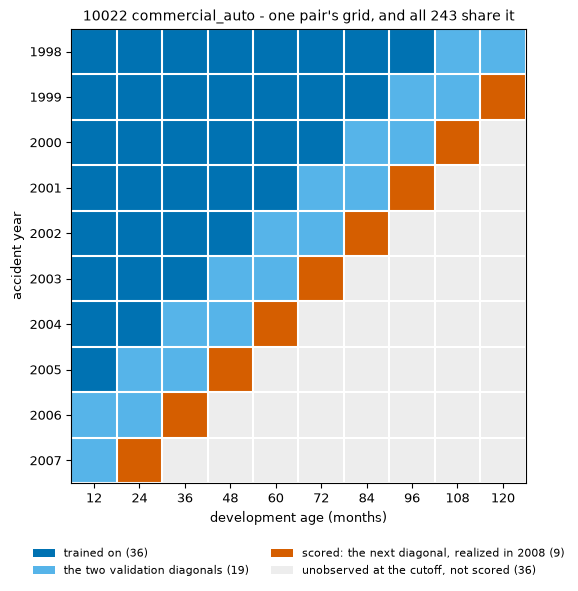

10 accident years x 10 development ages = 100 cells: 55 observed at 2007-12-31 (19 of them held out for validation), 9 scored, 36 unobserved.
cells excluded from the next diagonal on this pair: 0


In [9]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


def _locations(frame):
    """(origin_period, dev_lag) pairs of a frame, as a hashable set."""
    return frozenset(
        zip(
            pd.to_datetime(frame["origin_period"]).dt.date,
            frame["dev_lag"].astype(int),
            strict=True,
        )
    )


_tr = tri.as_of(AS_OF).expr.execute()
_tr = _tr[_tr["field"] == FIELD]
_observed = {k: _locations(g) for k, g in _tr.groupby(["company_code", "line_of_business"])}
_scored = {k: _locations(v.frame) for k, v in cells.items()}
_beyond = {k: _locations(v.excluded) for k, v in cells.items()}

# One grid speaks for the cohort set only if every pair has that grid: same accident
# years, same development ages, same scored locations, same exclusions.
assert len({(_observed[k], _scored[k], _beyond[k]) for k in PAIRS}) == 1

_key = PAIRS[0]
_origins = sorted({o for o, _ in _observed[_key]})
_devs = sorted({d for _, d in _observed[_key] | _scored[_key]})
_oi = {o: i for i, o in enumerate(_origins)}
_di = {d: j for j, d in enumerate(_devs)}
_cal = {(o, d): _oi[o] + _di[d] for o in _origins for d in _devs}
_last_train = max(_cal[c] for c in _observed[_key])
VAL_DIAGONALS = 2

_TRAIN, _VALID, _SCORED, _FUTURE = 0, 1, 2, 3
_grid_img = np.full((len(_origins), len(_devs)), _FUTURE)
for _o, _d in _observed[_key]:
    _grid_img[_oi[_o], _di[_d]] = _VALID if _cal[(_o, _d)] > _last_train - VAL_DIAGONALS else _TRAIN
for _o, _d in _scored[_key]:
    _grid_img[_oi[_o], _di[_d]] = _SCORED

_colors = ["#0072B2", "#56B4E9", "#D55E00", "#EDEDED"]
_labels = [
    f"trained on ({int((_grid_img == _TRAIN).sum())})",
    f"the two validation diagonals ({int((_grid_img == _VALID).sum())})",
    f"scored: the next diagonal, realized in 2008 ({int((_grid_img == _SCORED).sum())})",
    f"unobserved at the cutoff, not scored ({int((_grid_img == _FUTURE).sum())})",
]

fig, ax = plt.subplots(figsize=(7.2, 5.8), layout="constrained")
ax.imshow(_grid_img, cmap=ListedColormap(_colors), vmin=0, vmax=3)
ax.set_xticks(range(len(_devs)), [str(d) for d in _devs], fontsize=9)
ax.set_yticks(range(len(_origins)), [str(o.year) for o in _origins], fontsize=9)
ax.set_xticks(np.arange(-0.5, len(_devs)), minor=True)
ax.set_yticks(np.arange(-0.5, len(_origins)), minor=True)
ax.grid(which="minor", color="white", lw=1.5)
ax.tick_params(which="minor", length=0)
ax.set_xlabel("development age (months)", fontsize=9)
ax.set_ylabel("accident year", fontsize=9)
ax.set_title(f"{_key[0]} {_key[1]} - one pair's grid, and all {len(PAIRS)} share it", fontsize=10)
ax.legend(
    handles=[Patch(facecolor=c, label=t) for c, t in zip(_colors, _labels, strict=True)],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    fontsize=8,
    frameon=False,
)
plt.show()

print(
    f"{len(_origins)} accident years x {len(_devs)} development ages = {_grid_img.size} cells: "
    f"{int((_grid_img < _SCORED).sum())} observed at {AS_OF} "
    f"({int((_grid_img == _VALID).sum())} of them held out for validation), "
    f"{int((_grid_img == _SCORED).sum())} scored, "
    f"{int((_grid_img == _FUTURE).sum())} unobserved."
)
print(f"cells excluded from the next diagonal on this pair: {len(_beyond[_key])}")

## Entry capabilities

A forecast carries two independent capabilities, and the separation is what lets one board
hold entries of very different shapes:

* `ScoresHeldout` -> `log_lik_at()` -> a normalized predictive density;
* `PredictsHeldout` -> `predict_at()` -> predictive draws, and hence CRPS.

The continuous ranked probability score (CRPS) generalizes absolute error to a
distributional forecast: it is the average absolute difference between a draw from the
forecast and the realized value, less half the average absolute difference between two
independent draws. For a point forecast it reduces to absolute error; lower is better.

A third column matters in this notebook and did not in the earlier ones: whether the entry
has a **native point**. `mack`, `mcl` and `tlrn` each compute a deterministic forecast that
is not the mean of their draws, and `reserve_rows(point="native")` reads it. Everything
else contributes the draw mean, and the reserve table records which.

Two rows are new. `mcl` is the full-matrix multivariate chain ladder; like `sur` it
subclasses neither held-out mixin, so neither appears in a per-cell score column. `tlrn`
has draws, but only one per company, so it subclasses neither mixin either: a company-level
spread cannot answer a per-cell question, and claiming the capability would put a company's
uncertainty on cells that never carried one.

The unit a fit covers differs too. `mack` is one company-line pair. `mcl` and `sur` are one
company each. The pooled neural entries and `tlrn` are fitted once over the whole cohort
set.

In [10]:
COHORT_UNIT = {
    "mack": "company-line pair",
    "mcl": "company",
    "sur": "company",
    "tlrn": "all companies, one fit",
    "nn_transformer": "all pairs, one fit",
    "nn_transformer_ml": "all companies, one fit",
    "deeptriangle": "all pairs, one fit",
    "mdn": "all pairs, one fit",
    "resnet": "all pairs, one fit",
}
roster = (
    pd.DataFrame(
        [
            {
                "entry": name,
                "family": cls.family,
                "density": issubclass(cls, ScoresHeldout),
                "draws (CRPS)": issubclass(cls, PredictsHeldout),
                "native point": callable(getattr(cls, "point", None)),
                "cohort unit": COHORT_UNIT.get(name, "-"),
                "config_class": getattr(cls.config_class, "__name__", "-"),
            }
            for name in gallery.list()
            for cls in [gallery.get(name)]
        ]
    )
    .sort_values(["family", "entry"])
    .reset_index(drop=True)
)
print(
    f"{len(roster)} registered entries; "
    f"{roster['density'].sum()} density, {roster['draws (CRPS)'].sum()} draws, "
    f"{roster['native point'].sum()} native point"
)
IN_THIS_STUDY = list(COHORT_UNIT)
display(roster[roster["entry"].isin(IN_THIS_STUDY)].reset_index(drop=True))

18 registered entries; 10 density, 14 draws, 3 native point


,entry,family,density,draws (CRPS),native point,cohort unit,config_class
0,mack,deterministic,False,True,True,company-line pair,-
1,deeptriangle,nn,True,True,False,"all pairs, one fit",DeepTriangleConfig
2,mdn,nn,True,True,False,"all pairs, one fit",MDNConfig
3,nn_transformer,nn,True,True,False,"all pairs, one fit",TransformerConfig
4,nn_transformer_ml,nn,True,True,False,"all companies, one fit",TransformerMLConfig
5,resnet,nn,True,True,False,"all pairs, one fit",ResNetConfig
6,tlrn,nn,False,False,True,"all companies, one fit",TLRNConfig
7,mcl,statistical,False,False,True,company,-
8,sur,statistical,False,False,False,company,-


### The scoring helpers

Four helpers carry the notebook. They are written out in full because they are the API
surface it exists to show.

`forecast_for` turns one fitted entry and one pair's held-out cells into one
`CohortForecast`. `Absence` is why a missing array is never a bare `None`: a board has to
distinguish an entry with no density at all from a run that refused one cohort. The
vocabulary is closed - `fit_failed`, `no_cell_sampler`, `no_predictive_density`,
`not_offered`, `scorer_not_implemented`, `scoring_refused`.

`reserves_for` is `reserve_rows` with this study's arguments filled in, plus the model
name. It is what the 120-month and company boards are built from.

`next_points_for` reads each model's deterministic forecast at the nine held-out cells. The
four routes differ because the models do: `mack` reads its completed triangle, `mcl` and
`sur` take one step of their fitted transitions from the latest diagonal, `tlrn` reads its
projected cumulative grid, and the pooled neural entries take the mean of their rollout
draws.

`record` keeps a refusal instead of ending the run.

In [11]:
refusals: list[dict] = []
fit_seconds: dict[str, float] = {}


def forecast_for(name, entry, key, *, field=FIELD, task=TASK):
    """One fitted entry + one pair's held-out cells -> one CohortForecast."""
    kw = {}
    if isinstance(entry, ScoresHeldout):
        try:
            kw["log_density"] = entry.log_lik_at(cells[key], field=field)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="density", error=repr(exc)[:200]))
            kw["density_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        # Permanent and about the ENTRY: it states no observation model.
        kw["density_absence"] = Absence("no_predictive_density")

    if isinstance(entry, PredictsHeldout):
        try:
            kw["draws"] = entry.predict_at(cells[key], field=field, seed=SEED_DRAW)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="draws", error=repr(exc)[:200]))
            kw["draws_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        kw["draws_absence"] = Absence("no_cell_sampler")

    return CohortForecast(model=name, task=task, cells=cells[key], field=field, **kw)


def reserves_for(name, entry, *, point, predict_kwargs=None):
    """reserve_rows with this study's arguments, tagged with the model name.

    `tri` is handed in as the full triangle for every entry. It already carries the
    selected pairs only, so a company's anchor cannot pick up a line the selection
    dropped, and it is restricted to the ten study accident years, so the 120-month
    outcome cannot pick up a later one.
    """
    rows = reserve_rows(
        entry,
        tri,
        as_of=AS_OF,
        loss_field=FIELD,
        premium_field=PREMIUM_FIELD,
        point=point,
        predict_kwargs=dict(predict_kwargs or {}),
    )
    return rows.assign(model=name)


def held_out_frame(key):
    """One pair's nine held-out cells, ordered as the entry's arrays are."""
    return cells[key].frame


def record(what, name, key, exc):
    """Keep a refusal rather than ending the run."""
    refusals.append(dict(model=name, cohort=key, axis=what, error=repr(exc)[:200]))


def refusal_summary():
    """The refusals so far, grouped, because one line per cohort would bury them."""
    if not refusals:
        return pd.DataFrame(columns=["model", "axis", "error (truncated)", "cohorts"])
    frame = pd.DataFrame(refusals)
    frame["error (truncated)"] = frame["error"].str.slice(0, 80)
    return (
        frame.groupby(["model", "axis", "error (truncated)"], as_index=False)
        .agg(cohorts=("cohort", "nunique"))
        .sort_values(["model", "axis"])
        .reset_index(drop=True)
    )


print(
    "helpers defined:",
    ", ".join(["forecast_for", "reserves_for", "held_out_frame", "record", "refusal_summary"]),
)

helpers defined: forecast_for, reserves_for, held_out_frame, record, refusal_summary
